# 正态分布

## 生成正态分布的数据

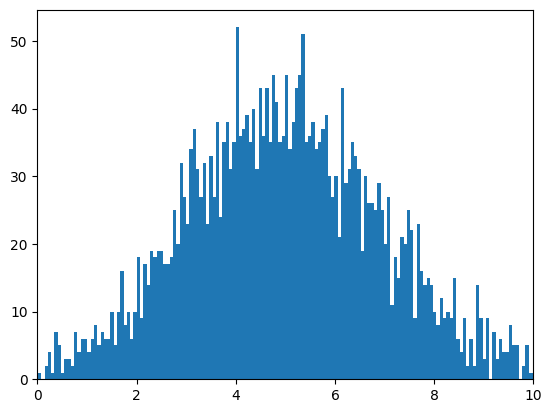

In [37]:
from numpy.random import normal
import matplotlib.pyplot as plt

mu = 5
sigma = 2
n = 3000

sample = normal(mu, sigma, n)
# print(sample)

plt.hist(sample, bins=200)
plt.xlim(0, 10)
plt.show()

## 正态分布的概率密度和累积分布函数

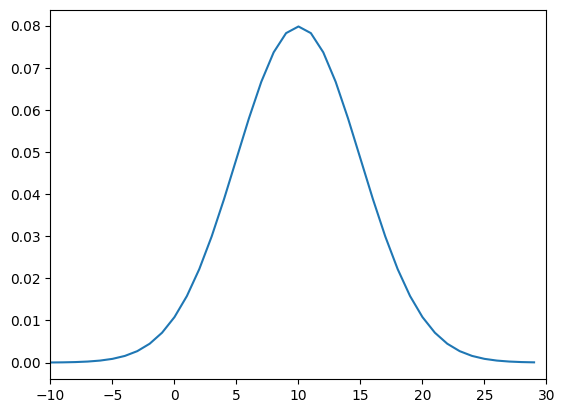

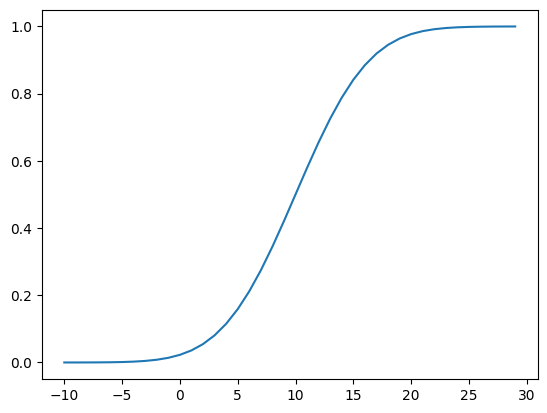

In [38]:
from scipy.stats import norm
import matplotlib.pyplot as plt

mu = 10
sigma = 5

dist = norm(mu, sigma)
values = [value for value in range(-10, 30)]

plt.plot(values,  dist.pdf(values))
plt.xlim(-10, 30)
plt.show()

plt.plot(values, dist.cdf(values))
plt.show()


## 正态分布数据分布规律

In [43]:
from scipy.stats import norm

mu = 100
sigma = 5
per = 0.995

dist = norm(mu, sigma)
low = dist.ppf((1-per)/2)
high = dist.ppf(1-(1-per)/2)

print(f'中间 {low:.2f} - {high:.2f} 占{100*per}%')

中间 85.96 - 114.04 占99.5%


In [49]:
from scipy.stats import norm

mu = 100
sigma = 5
num_of_sigma = 4

dist = norm(mu, sigma)
per = dist.cdf(mu + num_of_sigma * sigma) - dist.cdf(mu - num_of_sigma * sigma)

print(f'中间{num_of_sigma}个sigma占{per * 100:.1f}%')


中间4个sigma占100.0%


## 正态分布的概率密度和累积分布函数的定义

In [50]:
from sympy.stats import Normal, density, cdf
from sympy import Symbol, simplify, pprint

mu = Symbol("mu")
sigma = Symbol("sigma", positive=True)

x = Symbol("x")
norm_dist = Normal("norm", mu, sigma)

display(simplify(density(norm_dist)(x)))
display(simplify(cdf(norm_dist)(x)))

sqrt(2)*exp(-(mu - x)**2/(2*sigma**2))/(2*sqrt(pi)*sigma)

1/2 - erf(sqrt(2)*(mu - x)/(2*sigma))/2

## 正态分布的均值，中位数和众数

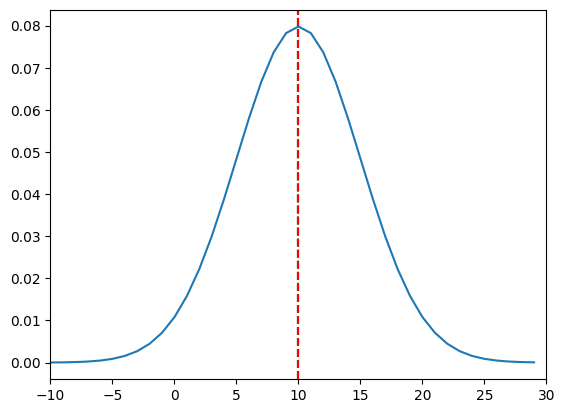

In [5]:
from scipy.stats import norm
import matplotlib.pyplot as plt

mu = 10
sigma = 5

dist = norm(mu, sigma)
values = [value for value in range(-10, 30)]

plt.plot(values,  dist.pdf(values))

mean, median = norm.mean(mu, sigma), norm.median(mu, sigma)
mode = mean

plt.axvline(x=mean, color='black', linestyle='dashed')
plt.axvline(x=median, color='green', linestyle='dashed')
plt.axvline(x=mode, color='red', linestyle='dashed')

plt.xlim(-10, 30)
plt.show()

# 指数分布

## 生成指数分布的数据

[0.42032591 0.10541821 0.24869028 ... 0.09915415 0.09613702 0.0334411 ]


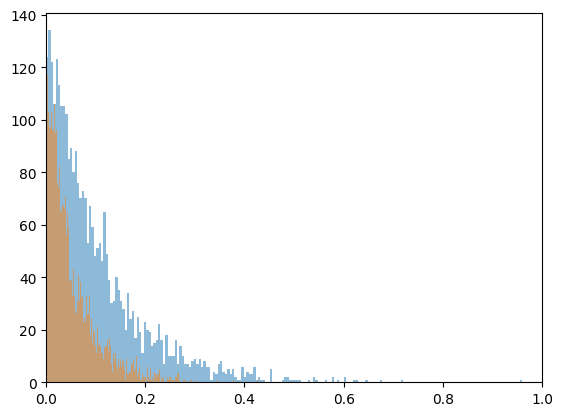

In [146]:
import numpy as np
import matplotlib.pyplot as plt

lam1 = 10
lam2 = 20

sample = np.random.exponential(scale=1/lam1, size=3000)
print(sample)
plt.hist(sample, bins=200, alpha=0.5)
plt.hist(np.random.exponential(scale=1/lam2, size=3000), bins=200, alpha=0.5)
plt.xlim(0, 1)
plt.show()

## 指数分布的概率密度和累计分布函数

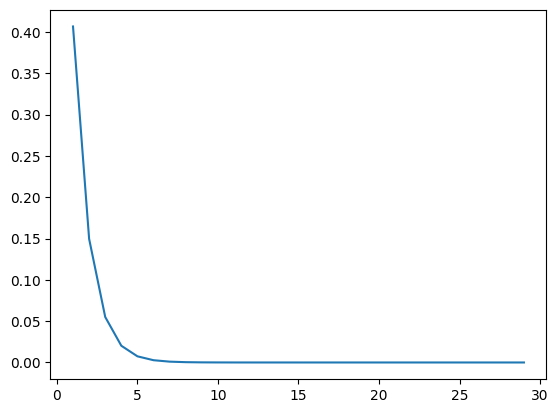

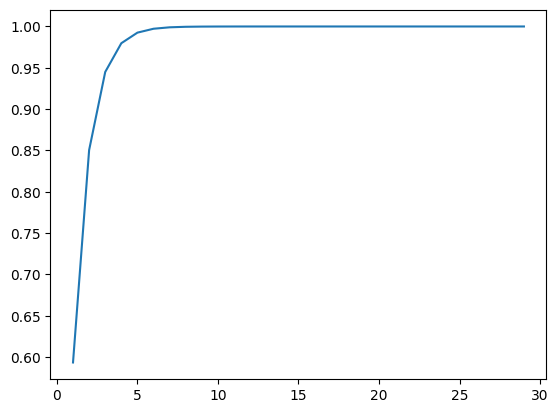

In [168]:
from scipy.stats import expon
import matplotlib.pyplot as plt

lam = 10

dist = expon(1/lam)
values = [value for value in range(1, 30)]

plt.plot(values,  dist.pdf(values))
plt.show()

plt.plot(values, dist.cdf(values))
plt.show()

## 指数分布的概率密度和累计分布函数的定义

In [172]:
from sympy.stats import Exponential, density, cdf
from sympy import Symbol, simplify, pprint

lmd = Symbol("lambda", positive=True)
x = Symbol("x")
dist = Exponential("dist", lmd)

display(simplify(density(dist)(x)))
display(simplify(cdf(dist)(x)))

lambda*exp(-lambda*x)

Piecewise((1 - exp(-lambda*x), x >= 0), (0, True))

## 指数分布的均值，中位数和众数

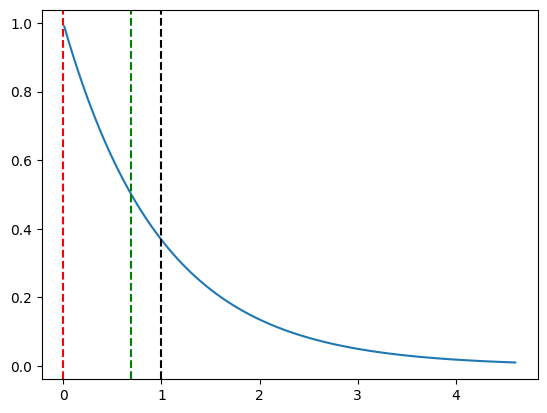

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon

# 指数分布参数
scale = 1.0  # 指数分布的尺度参数，也等于均值

# 计算指数分布的均值、中位数和众数
mean_exponential = scale
median_exponential = scale * np.log(2)
mode_exponential = 0  # 指数分布的众数总是0

# 生成指数分布的概率密度函数数据
x = np.linspace(expon.ppf(0.01, scale=scale), expon.ppf(0.99, scale=scale), 100)
y = expon.pdf(x, scale=scale)

plt.plot(x, y)

plt.axvline(x=mean_exponential, color='black', linestyle='--')
plt.axvline(x=median_exponential, color='green', linestyle='--')
plt.axvline(x=mode_exponential, color='red', linestyle='--')

plt.show()


# 泊松分布

## 生成泊松分布的数据

[54 51 48 ... 54 46 52]


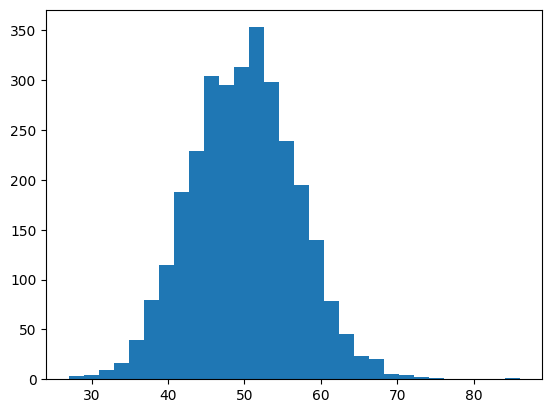

In [174]:
from numpy.random import poisson
import matplotlib.pyplot as plt

lam = 50  # λ
n = 3000

sample = poisson(lam, size=n)
print(sample)

plt.hist(sample, bins=30)
plt.show()

## 泊松分布的概率质量和累计分布函数

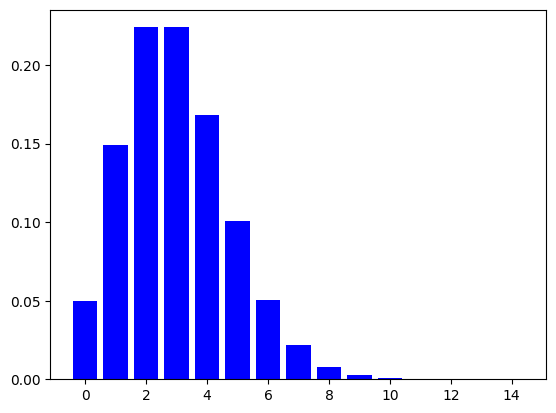

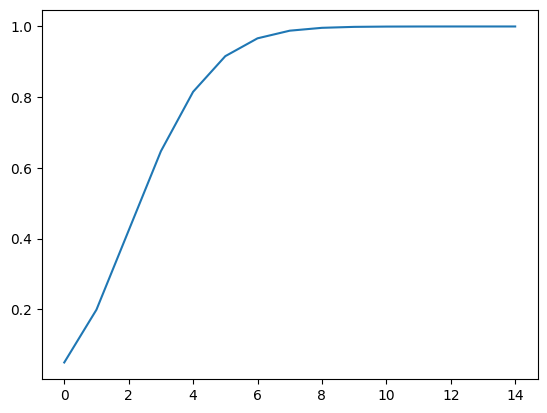

In [102]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

lambda_param = 3

x = np.arange(0, 15)

pmf = poisson.pmf(x, lambda_param)
cdf = poisson.cdf(x, lambda_param)

plt.bar(x, pmf, color='b')
plt.show()

plt.plot(x, cdf)
plt.show()


## 泊松分布的概率质量函数和累计分布函数的定义

In [110]:
from sympy.stats import Poisson, density, cdf
from sympy import Symbol, simplify


lam = Symbol("lambda", positive=True)
x = Symbol("x")

dist = Poisson("dist", lam)

display(simplify(density(dist)(x)))
display(simplify(cdf(dist)(x)))

lambda**x*exp(-lambda)/gamma(x + 1)

Piecewise((1 - lowergamma(floor(x) + 1, lambda)/gamma(floor(x) + 1), x >= 0), (0, True))

# 帕累托分布

## 生成帕累托分布的数据

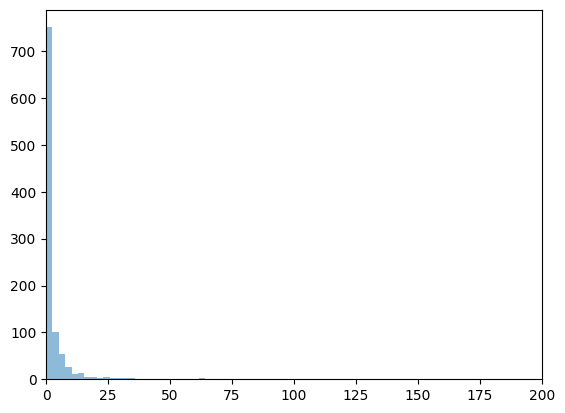

In [212]:
from numpy.random import pareto
alpha = 1.1
n = 1000

sample = pareto(alpha, n)
plt.hist(sample, bins=200, alpha=0.5)
plt.xlim(0, 200)
plt.show()

## 帕累托分布的概率密度函数和累积分布函数

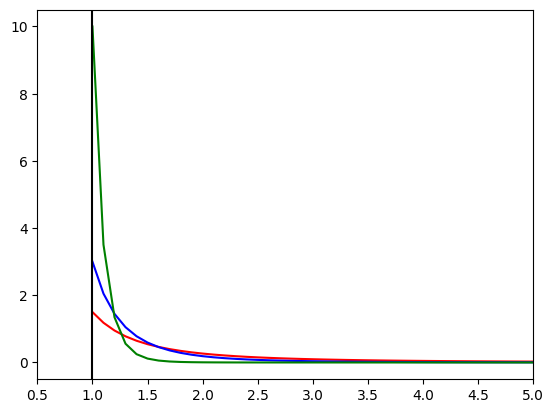

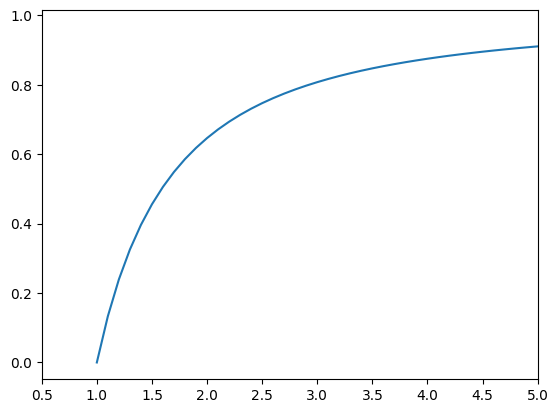

In [246]:
# pdf and cdf for a pareto distribution
from scipy.stats import pareto
from matplotlib import pyplot

# define distribution parameter
alpha = 1.5
# create distribution
dist = pareto(alpha)
dist2 = pareto(3)
dist3 = pareto(10)

# plot pdf
values = [value/10.0 for value in range(10, 100)]
probabilities = [dist.pdf(value) for value in values]

pyplot.plot(values, probabilities, color='r')
pyplot.plot(values, [dist2.pdf(value) for value in values], color='b')
pyplot.plot(values, [dist3.pdf(value) for value in values], color='g')
plt.axvline(x=1, color='black')
pyplot.xlim(0.5, 5)

pyplot.show()


# plot cdf
cprobs = [dist.cdf(value) for value in values]
pyplot.plot(values, cprobs)
pyplot.xlim(0.5, 5)
pyplot.show()

## 帕雷托分布的概率密度和累积分布函数的定义

In [2]:
from sympy.stats import Pareto, density, cdf
from sympy import Symbol, simplify

xm = Symbol("xm", positive=True)
alpha = Symbol("alpha", positive=True)
x = Symbol("x")


dist = Pareto("dist", xm, alpha)
display(simplify(density(dist)(x)))
display(simplify(cdf(dist)(x)))

alpha*x**(-alpha - 1)*xm**alpha

Piecewise((1 - xm**alpha/x**alpha, x >= xm), (0, True))

## 帕雷托分布百分位

80% of the data is below 4.00461111622391


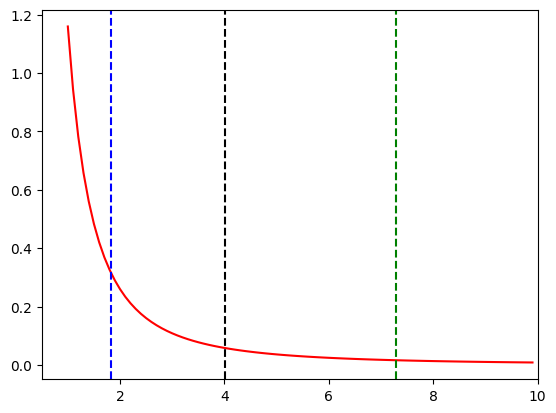

In [252]:
from scipy.stats import pareto
from matplotlib import pyplot

# 设置帕累托分布的参数
xm = 1  # 尺度参数
alpha = 1.16  # 形状参数


# create distribution
dist = pareto(alpha)

# 找到使得CDF达到80%的数据点
threshold = pareto.ppf(0.8, alpha, scale=xm)
print(f"80% of the data is below {threshold}")



# plot pdf
values = [value/10.0 for value in range(10, 100)]
probabilities = [dist.pdf(value) for value in values]
pyplot.plot(values, probabilities, color='r')

plt.axvline(x=threshold, color='black', linestyle='dashed')
plt.axvline(x=pareto.ppf(0.5, alpha, scale=xm), color='blue', linestyle='dashed')
plt.axvline(x=pareto.ppf(0.9, alpha, scale=xm), color='green', linestyle='dashed')
pyplot.xlim(0.5, 10)

pyplot.show()


## 帕累托分布的均值，中位数和众数

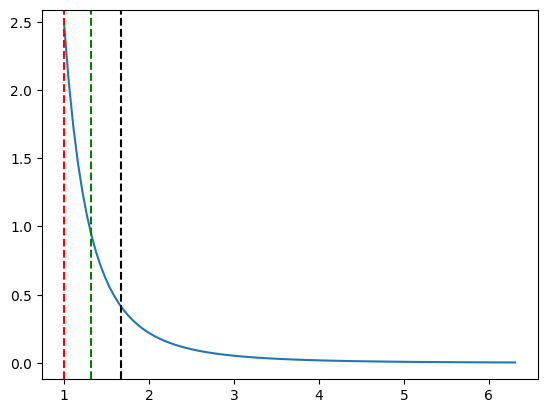

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pareto

# 帕累托分布参数
shape = 2.5
scale = 1.0

# 计算帕累托分布的均值、中位数和众数
mean_pareto = pareto.mean(shape, scale=scale)
median_pareto = pareto.median(shape, scale=scale)
mode_pareto = scale

x = np.linspace(pareto.ppf(0.01, shape, scale=scale), pareto.ppf(0.99, shape, scale=scale), 100)
y = pareto.pdf(x, shape, scale=scale)

plt.plot(x, y)

plt.axvline(x=mean_pareto, color='black', linestyle='dashed')
plt.axvline(x=median_pareto, color='green', linestyle='dashed')
plt.axvline(x=mode_pareto, color='red', linestyle='dashed')

plt.show()
